In [1]:
import os
import cv2
import json
import numpy as np
import random
import nibabel as nib
import matplotlib.pyplot as plt

In [2]:
img_data = np.load('/root/autodl-tmp/Data/Task07_Pancreas/crop_imagesTr/pancreas_001.npy')
print(img_data.shape, img_data.max(), img_data.min())

(68, 256, 256, 3) 0.99448556 0.027337719


In [2]:
img_data = nib.load('/root/autodl-tmp/Data/Task07_Pancreas/processed_imagesTr/pancreas_336.nii.gz').get_fdata()
mask_data = nib.load('/root/autodl-tmp/Data/Task07_Pancreas/processed_labelsTr/pancreas_336.nii.gz').get_fdata()

In [3]:
print(img_data.shape, np.max(img_data),np.min(img_data))
print(mask_data.shape,np.unique(mask_data))

(475, 475, 105) 1.226762056350708 -0.20759283006191254
(475, 475, 105) [0. 1. 2.]


In [6]:
pro_img = (img_data - img_data.min()) / (img_data.max() - img_data.min())

In [5]:
img_data = np.fliplr(np.rot90(img_data, 1))
pro_img = np.fliplr(np.rot90(pro_img, 1))
mask_data = np.fliplr(np.rot90(mask_data, 1))

In [2]:
img_data = np.load('/root/autodl-tmp/Data/Task07_Pancreas/crop_imagesTr_512/pancreas_370.npy')
mask_data = np.load('/root/autodl-tmp/Data/Task07_Pancreas/crop_labelsTr_512/pancreas_370.npy')
print(img_data.shape, mask_data.shape, np.unique(mask_data))

(76, 512, 512, 3) (76, 512, 512) [0 1 2]


In [4]:
for i in range(img_data.shape[0]):
    print(img_data[i].max(), img_data[i].min())

1.0031701 0.023352876
0.9926598 0.027776126
0.94537175 0.055929292
0.9419125 0.058523476
0.94283795 0.00040857698
0.9532088 -0.017705865
0.948653 0.0070054736
0.9343105 0.05980804
0.93294096 0.054855682
0.96215725 0.014663436
0.97804034 0.0051924484
0.9622766 0.022638965
0.9347581 0.05704111
0.92695844 0.054382637
0.9547362 0.034915507
0.94534224 0.027973177
0.94123995 0.04557105
0.92253995 0.05534461
0.90331894 0.05856581
0.9276719 0.020840682
0.936206 0.002789682
0.9477816 0.025726892
0.9355222 0.05207098
0.9175385 0.049812287
0.9280757 0.036165666
0.9326377 0.025070302
0.92082167 0.03518819
0.9043949 0.050309945
0.92359984 0.06403397
0.97911555 0.03748612
1.0144957 0.027312657
1.0084553 0.034977887
0.958132 0.048238188
0.90915585 0.05577349
0.9466227 0.019904062
0.9607514 -0.0058171344
0.95057714 0.0056976844
0.92934316 0.05201562
0.91899 0.06483148
0.9397497 0.0519587
0.96416605 0.041813463
0.96569145 0.04279338
0.93699855 0.04880282
0.92019117 0.058948692
0.93856597 0.03936378
0.9

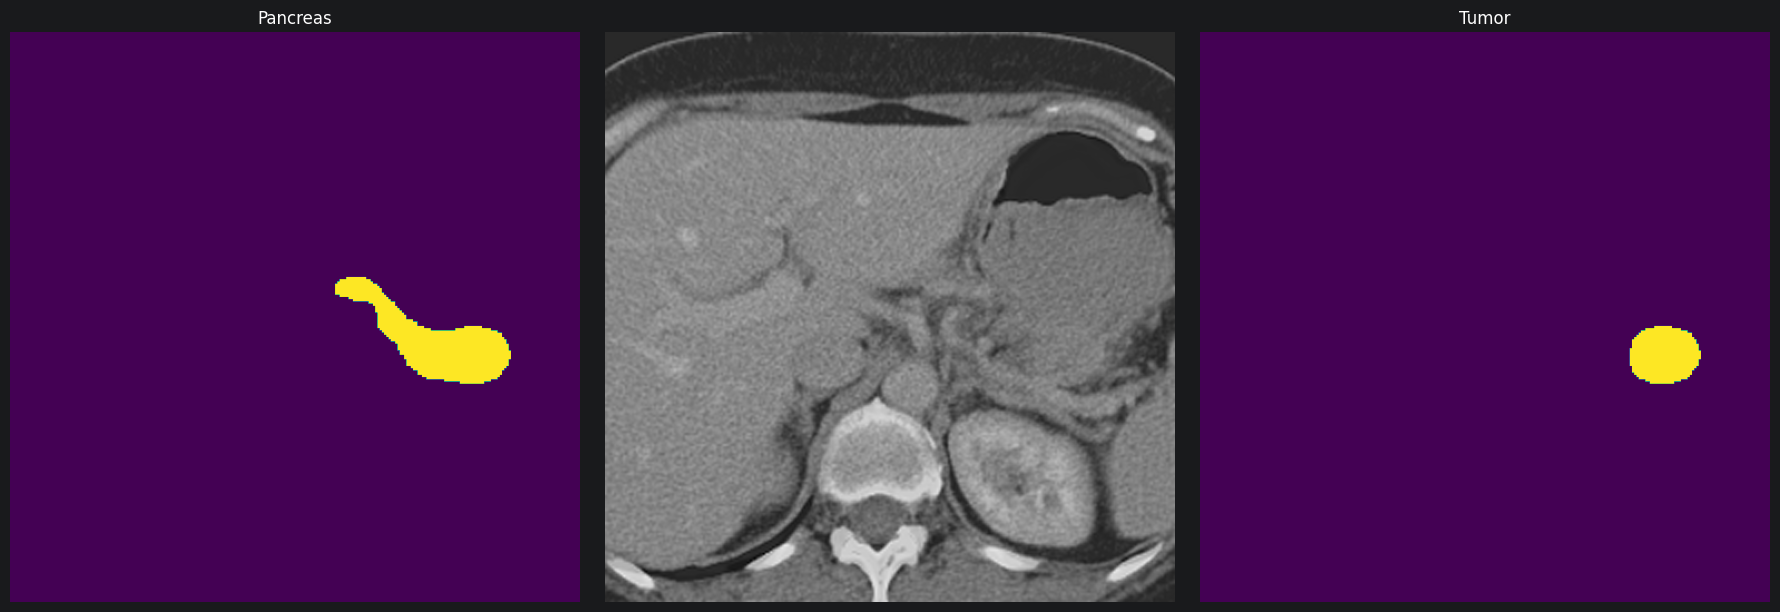

In [18]:
s = 74
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 显示第一张通道的图像 (因为我们把灰度图复制了 3 个通道)
axes[0].imshow(((mask_data==1)|(mask_data==2))[s,:,:], cmap='viridis')
axes[0].set_title(f"Pancreas")
axes[0].axis('off')

# 显示对应的 Mask (胰腺和肿瘤会在颜色上有所区分)
axes[1].imshow(pro_img[s,:,:], cmap='gray')
axes[1].set_title(f"")
axes[1].axis('off')

axes[2].imshow((mask_data==2)[s,:,:], cmap='viridis')
axes[2].set_title(f"Tumor")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [24]:
import os
import json
import pickle

def prune_bad_slices(json_path, pickle_path, target_id="pancreas_336", bad_z_start=24):
    print(f"🏥 准备执行局部切除手术：保留病人 [{target_id}] 的健康切片，切除 Z >= {bad_z_start} 的坏死区域")

    def process_data(data, file_type):
        if target_id in data:
            original_slices = data[target_id]["slices_info"]
            original_count = len(original_slices)

            # 【核心逻辑】：只保留 relative_z 小于 24 的健康切片
            healthy_slices = [s for s in original_slices if s["relative_z"] < bad_z_start]
            healthy_count = len(healthy_slices)

            # 边缘情况防御：如果切完发现一张都不剩了，那就彻底删掉这个病人
            if healthy_count == 0:
                print(f"⚠️ {file_type}: 过滤后该病人已无可用切片，执行全盘删除。")
                del data[target_id]
            else:
                data[target_id]["slices_info"] = healthy_slices
                print(f"✅ {file_type}: 成功剔除坏死切片！切片数变化: {original_count} -> {healthy_count}")
            return True
        else:
            print(f"⚠️ {file_type}: 未找到病人 {target_id}。")
            return False

    # 1. 处理 JSON (方便人类肉眼检查)
    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            json_data = json.load(f)

        if process_data(json_data, "JSON"):
            with open(json_path, 'w', encoding='utf-8') as f:
                # 依然保持缩进格式，方便你打开检查
                json.dump(json_data, f, indent=2)
    else:
        print(f"❌ 找不到文件: {json_path}")

    # 2. 处理 Pickle (实际训练读取的文件)
    if os.path.exists(pickle_path):
        with open(pickle_path, 'rb') as f:
            pickle_data = pickle.load(f)

        if process_data(pickle_data, "Pickle"):
            with open(pickle_path, 'wb') as f:
                pickle.dump(pickle_data, f)
    else:
        print(f"❌ 找不到文件: {pickle_path}")

    print("🎉 局部切除手术完成！你的数据集既保住了健康数据，又消灭了导致梯度崩溃的隐患！")

if __name__ == "__main__":
    # 请替换为你的实际路径
    JSON_FILE = "/root/autodl-tmp/Data/Task07_Pancreas/MDC512_sep_annotations.json"
    PICKLE_FILE = "/root/autodl-tmp/Data/Task07_Pancreas/MDC512_sep_annotations.p"

    prune_bad_slices(JSON_FILE, PICKLE_FILE, target_id="pancreas_336", bad_z_start=24)

🏥 准备执行局部切除手术：保留病人 [pancreas_336] 的健康切片，切除 Z >= 24 的坏死区域
✅ JSON: 成功剔除坏死切片！切片数变化: 91 -> 28
✅ Pickle: 成功剔除坏死切片！切片数变化: 91 -> 28
🎉 局部切除手术完成！你的数据集既保住了健康数据，又消灭了导致梯度崩溃的隐患！


In [7]:
from bert.tokenization_bert import BertTokenizer

# 指向你下载 RadBERT 的文件夹
model_path = '/root/autodl-tmp/pretrained_weights/' #RadBERT/
# tokenizer = BertTokenizer.from_pretrained(model_path)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

word_list = ['abnormal', 'unhealthy', 'bulging',"normal", "healthy","pancreas", "pancreas organ", "pancreatic tissue","tumor", "mass", "lesion", "pancreatic tumor", "neoplasm","irregular", "curved", "complex", "lobulated", "elongated", "narrow", "thin","round", "oval", "bulbous","solid", "normal-shaped", 'distinct']
for word in word_list:
    tokens = tokenizer.tokenize(word)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f"原单词: {word}")
    print(f"拆分后的 Tokens: {tokens}")
    print(f"对应的 ID 序列: {token_ids}")

原单词: abnormal
拆分后的 Tokens: ['abnormal']
对应的 ID 序列: [19470]
原单词: unhealthy
拆分后的 Tokens: ['un', '##hea', '##lth', '##y']
对应的 ID 序列: [4895, 20192, 24658, 2100]
原单词: bulging
拆分后的 Tokens: ['bulging']
对应的 ID 序列: [27569]
原单词: normal
拆分后的 Tokens: ['normal']
对应的 ID 序列: [3671]
原单词: healthy
拆分后的 Tokens: ['healthy']
对应的 ID 序列: [7965]
原单词: pancreas
拆分后的 Tokens: ['pan', '##cre', '##as']
对应的 ID 序列: [6090, 16748, 3022]
原单词: pancreas organ
拆分后的 Tokens: ['pan', '##cre', '##as', 'organ']
对应的 ID 序列: [6090, 16748, 3022, 5812]
原单词: pancreatic tissue
拆分后的 Tokens: ['pan', '##cre', '##atic', 'tissue']
对应的 ID 序列: [6090, 16748, 12070, 8153]
原单词: tumor
拆分后的 Tokens: ['tumor']
对应的 ID 序列: [13656]
原单词: mass
拆分后的 Tokens: ['mass']
对应的 ID 序列: [3742]
原单词: lesion
拆分后的 Tokens: ['les', '##ion']
对应的 ID 序列: [4649, 3258]
原单词: pancreatic tumor
拆分后的 Tokens: ['pan', '##cre', '##atic', 'tumor']
对应的 ID 序列: [6090, 16748, 12070, 13656]
原单词: neoplasm
拆分后的 Tokens: ['neo', '##pl', '##as', '##m']
对应的 ID 序列: [9253, 24759, 3022, 2213]
原单词: